# Final Project: Titanic Survival Analysis

## Data Science Final Project

This project analyzes the Titanic dataset to understand factors that influenced passenger survival rates. We will explore the data, perform statistical tests, examine variable relationships, build predictive models, and visualize our findings.

**Dataset Source**: https://www.kaggle.com/c/titanic/data

In [1]:
# Import necessary libraries
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy import stats
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Description

### 1.1 Data Source and Loading

In [2]:
# Load the training data from local file
df = pd.read_csv("traintitanic.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1.2 Data Overview and Information

The Titanic dataset contains information about passengers aboard the RMS Titanic. Let's examine the structure and characteristics of the data.

In [3]:
# Display basic information about the dataset
print("Dataset Info:")
print("=" * 50)
df.info()

print("\n\nDataset Description:")
print("=" * 50)
df.describe()

print("\n\nFirst few rows:")
print("=" * 50)
df.head(10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Dataset Description:


First few rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### 1.3 Data Characteristics

**Numerical Features:**
- `PassengerId`: Unique identifier for each passenger
- `Survived`: Target variable (0 = No, 1 = Yes)
- `Pclass`: Ticket class (1 = First, 2 = Second, 3 = Third)
- `Age`: Passenger age in years
- `SibSp`: Number of siblings/spouses aboard
- `Parch`: Number of parents/children aboard
- `Fare`: Ticket fare

**Categorical Features:**
- `Name`: Passenger name
- `Sex`: Gender (male/female)
- `Ticket`: Ticket number
- `Cabin`: Cabin number
- `Embarked`: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

### 1.4 Missing Data Analysis

In [4]:
# Check for missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Data Summary:")
print("=" * 50)
print(missing_df)

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Total observations: {len(df)}")

Missing Data Summary:
          Missing Count  Percentage
Cabin               687   77.104377
Age                 177   19.865320
Embarked              2    0.224467

Total missing values: 866
Total observations: 891


**Missing Data Concerns:**
- **Age**: 177 missing values (19.9% of data) - This is a significant amount. We'll need to handle this carefully.
- **Cabin**: 687 missing values (77.1% of data) - Too many missing values to be useful for analysis.
- **Embarked**: 2 missing values (0.2% of data) - Minimal impact, can be dropped or imputed.

**Data Cleaning Strategy:**
1. Drop the `Cabin` column due to excessive missing data
2. Impute missing `Age` values using median age grouped by Pclass and Sex
3. Drop rows with missing `Embarked` values (only 2 rows)

In [5]:
# Data cleaning
df_clean = df.copy()

# Drop Cabin column (too many missing values)
df_clean = df_clean.drop(columns=['Cabin'])

# Drop rows with missing Embarked (only 2 rows)
df_clean = df_clean.dropna(subset=['Embarked'])

# Create Sex_num for grouping
df_clean['Sex_num'] = (df_clean['Sex'] == 'male').astype(int)

# Impute missing Age values using median grouped by Pclass and Sex
df_clean['Age'] = df_clean['Age'].fillna(
    df_clean.groupby(['Pclass', 'Sex_num'])['Age'].transform('median')
)

# Create dummy variables for Embarked
df_clean['C'] = (df_clean['Embarked'] == 'C').astype(int)
df_clean['Q'] = (df_clean['Embarked'] == 'Q').astype(int)
df_clean['S'] = (df_clean['Embarked'] == 'S').astype(int)

print("After cleaning:")
print(f"Shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"\nSurvival rate: {df_clean['Survived'].mean():.3f}")

After cleaning:
Shape: (889, 15)
Missing values: 0

Survival rate: 0.382


## 2. Statistical Test

We will perform a two-sample t-test to compare the mean age of survivors vs. non-survivors.

**Null Hypothesis (H₀)**: The mean age of survivors equals the mean age of non-survivors (μ₁ = μ₂)

**Alternative Hypothesis (H₁)**: The mean age of survivors differs from the mean age of non-survivors (μ₁ ≠ μ₂)

In [6]:
# Two-sample t-test: Age of survivors vs. non-survivors
survivors_age = df_clean[df_clean['Survived'] == 1]['Age']
non_survivors_age = df_clean[df_clean['Survived'] == 0]['Age']

# Perform two-sample t-test
t_stat, p_value = stats.ttest_ind(survivors_age, non_survivors_age)

print("Two-Sample T-Test: Age of Survivors vs. Non-Survivors")
print("=" * 60)
print(f"Survivors - Mean age: {survivors_age.mean():.2f}, Std: {survivors_age.std():.2f}, n={len(survivors_age)}")
print(f"Non-survivors - Mean age: {non_survivors_age.mean():.2f}, Std: {non_survivors_age.std():.2f}, n={len(non_survivors_age)}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Two-Sample T-Test: Age of Survivors vs. Non-Survivors
Survivors - Mean age: 27.98, Std: 13.92, n=340
Non-survivors - Mean age: 29.74, Std: 12.82, n=549

T-statistic: -1.9223
P-value: 0.0549


**Interpretation:**

Based on the t-test results, the p-value is 0.0549. At a significance level of α=0.05, we fail to reject H₀. There is no statistically significant difference in mean age between survivors and non-survivors.


## 3. Variable Relationships

Let's examine correlations between variables to understand relationships in the data.

In [7]:
# Calculate correlation matrix for numerical variables
numeric_vars = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_num']
correlation_matrix = df_clean[numeric_vars].corr()

print("Correlation Matrix:")
print("=" * 50)
print(correlation_matrix.round(3))

# Focus on correlations with Survived
print("\n\nCorrelations with Survival:")
print("=" * 50)
survival_corr = correlation_matrix['Survived'].sort_values(ascending=False)
print(survival_corr)

Correlation Matrix:
          Survived  Pclass    Age  SibSp  Parch   Fare  Sex_num
Survived     1.000  -0.336 -0.064 -0.034  0.083  0.255   -0.542
Pclass      -0.336   1.000 -0.411  0.082  0.017 -0.548    0.128
Age         -0.064  -0.411  1.000 -0.249 -0.175  0.120    0.108
SibSp       -0.034   0.082 -0.249  1.000  0.415  0.161   -0.116
Parch        0.083   0.017 -0.175  0.415  1.000  0.218   -0.248
Fare         0.255  -0.548  0.120  0.161  0.218  1.000   -0.180
Sex_num     -0.542   0.128  0.108 -0.116 -0.248 -0.180    1.000


Correlations with Survival:
Survived    1.000000
Fare        0.255290
Parch       0.083151
SibSp      -0.034040
Age        -0.064411
Pclass     -0.335549
Sex_num    -0.541585
Name: Survived, dtype: float64


### Key Correlation: Sex and Survival

Let's examine the relationship between sex (encoded as Sex_num: 0=female, 1=male) and survival:

**Interpretation:**

The correlation coefficient of -0.5416 indicates a strong negative relationship. This means that being male (Sex_num=1) is negatively correlated with survival. Female passengers had a 74.0% survival rate, while male passengers had an 18.9% survival rate.


In [8]:
# Correlation between Sex and Survival
sex_survival_corr = df_clean['Sex_num'].corr(df_clean['Survived'])
print(f"Correlation between Sex (male=1, female=0) and Survival: {sex_survival_corr:.4f}")

# Detailed breakdown
print("\nSurvival rates by Sex:")
print("=" * 50)
sex_survival = df_clean.groupby('Sex')['Survived'].agg(['mean', 'count'])
sex_survival.columns = ['Survival Rate', 'Count']
print(sex_survival)

Correlation between Sex (male=1, female=0) and Survival: -0.5416

Survival rates by Sex:
        Survival Rate  Count
Sex                         
female       0.740385    312
male         0.188908    577


## 4. Causal Interpretation

**Can the correlation between Sex and Survival be interpreted causally?**

**Answer: No, this correlation should NOT be interpreted causally.**

**Reasons:**
1. **Confounding Variables**: The relationship between sex and survival is likely confounded by other factors:
   - **"Women and children first" policy**: Historical accounts suggest that during the evacuation, there was a cultural norm prioritizing women and children for lifeboats, which would create a spurious correlation.
   - **Location on ship**: Women and children may have been located in areas closer to lifeboats or upper decks.
   - **Socioeconomic status**: Gender may be correlated with other factors like class, which also affects survival.

2. **Reverse Causality**: Survival cannot cause sex, but the relationship is not a direct causal effect of sex itself.

3. **Omitted Variable Bias**: Without controlling for other factors (like the evacuation procedures, location on ship, etc.), we cannot establish causality.

4. **Observational Data**: This is observational data from a historical event, not a randomized experiment. We cannot rule out that the relationship is due to other unobserved factors.

**Conclusion**: While there is a strong correlation between sex and survival, this is likely due to the "women and children first" evacuation protocol and other confounding factors, rather than a direct causal effect of sex on survival.

## 5. Predictive Model

We will build a logistic regression model to predict passenger survival. Logistic regression is appropriate here because our target variable (Survived) is binary (0 or 1).

### 5.1 Prepare Features

In [9]:
# Select features for the model
# We exclude Ticket and Cabin because:
# - Ticket: Mostly unique identifiers, not meaningful for prediction
# - Cabin: Too many missing values (77% missing)
# - Name: Unique identifiers, though could be engineered for titles
# - PassengerId: Just an index

feature_columns = ["Pclass", "Sex_num", "Fare", "Age", "C", "S", "Q", "Parch", "SibSp"]

# Prepare feature matrix and target
X = df_clean[feature_columns]
y = df_clean['Survived']

print("Feature columns:", feature_columns)
print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nSurvival rate: {y.mean():.3f}")

Feature columns: ['Pclass', 'Sex_num', 'Fare', 'Age', 'C', 'S', 'Q', 'Parch', 'SibSp']
Feature matrix shape: (889, 9)
Target distribution:
Survived
0    549
1    340
Name: count, dtype: int64

Survival rate: 0.382


### 5.2 Train-Test Split

In [10]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-Test Split:")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set survival rate: {y_train.mean():.3f}")
print(f"Test set survival rate: {y_test.mean():.3f}")

Train-Test Split:
Training set: 711 samples (80.0%)
Test set: 178 samples (20.0%)

Training set survival rate: 0.383
Test set survival rate: 0.382


### 5.3 Train Logistic Regression Model

In [11]:
# Train logistic regression model
# Parameters:
# - penalty='l2': L2 regularization (Ridge) to prevent overfitting
# - C=1.0: Inverse of regularization strength (smaller C = stronger regularization)
# - max_iter=1000: Maximum iterations for convergence

lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained")
print("=" * 50)
print(f"Model parameters: penalty='l2', C=1.0, max_iter=1000")
print(f"Number of iterations: {lr_model.n_iter_[0]}")

Logistic Regression Model Trained
Model parameters: penalty='l2', C=1.0, max_iter=1000
Number of iterations: 251


**Interpretation:**

Positive coefficients increase the log-odds of survival, while negative coefficients decrease the log-odds of survival.

**Key Findings:**
- Features with positive coefficients (increasing survival probability): Q (Embarkation port Queenstown), C (Embarkation port Cherbourg), Fare (ticket fare)
- Features with negative coefficients (decreasing survival probability): Age, Parch (number of parents/children), SibSp (number of siblings/spouses), S (Embarkation port Southampton), Pclass (passenger class), Sex_num (gender, male=1)

The coefficient for Sex_num is the largest in magnitude (-2.5254), indicating that gender is the most important factor affecting survival probability.


### 5.4 Model Interpretation

In [12]:
# Display model coefficients
coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_[0]
})
coefficients = coefficients.sort_values('Coefficient', ascending=False)

print("Logistic Regression Coefficients:")
print("=" * 50)
print(coefficients.to_string(index=False))

Logistic Regression Coefficients:
Feature  Coefficient
      Q     0.261970
      C     0.009852
   Fare     0.002466
    Age    -0.040439
  Parch    -0.086219
  SibSp    -0.262216
      S    -0.281325
 Pclass    -1.105598
Sex_num    -2.525424


### 5.5 In-Sample Performance (Training Set)

In [13]:
# Predictions on training set
y_train_pred = lr_model.predict(X_train)
y_train_proba = lr_model.predict_proba(X_train)[:, 1]

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

print("In-Sample Performance (Training Set):")
print("=" * 50)
print(f"Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

print("\nClassification Report:")
print("-" * 50)
print(classification_report(y_train, y_train_pred, target_names=['Did Not Survive', 'Survived']))

print("\nConfusion Matrix:")
print("-" * 50)
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)
print(f"\nTrue Negatives: {cm_train[0,0]}, False Positives: {cm_train[0,1]}")
print(f"False Negatives: {cm_train[1,0]}, True Positives: {cm_train[1,1]}")

In-Sample Performance (Training Set):
Accuracy: 0.8073 (80.73%)

Classification Report:
--------------------------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.87      0.85       439
       Survived       0.77      0.71      0.74       272

       accuracy                           0.81       711
      macro avg       0.80      0.79      0.79       711
   weighted avg       0.81      0.81      0.81       711


Confusion Matrix:
--------------------------------------------------
[[382  57]
 [ 80 192]]

True Negatives: 382, False Positives: 57
False Negatives: 80, True Positives: 192


### 5.6 Out-of-Sample Performance (Test Set)

In [14]:
# Predictions on test set
y_test_pred = lr_model.predict(X_test)
y_test_proba = lr_model.predict_proba(X_test)[:, 1]

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Out-of-Sample Performance (Test Set):")
print("=" * 50)
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\nClassification Report:")
print("-" * 50)
print(classification_report(y_test, y_test_pred, target_names=['Did Not Survive', 'Survived']))

print("\nConfusion Matrix:")
print("-" * 50)
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)
print(f"\nTrue Negatives: {cm_test[0,0]}, False Positives: {cm_test[0,1]}")
print(f"False Negatives: {cm_test[1,0]}, True Positives: {cm_test[1,1]}")

print("\n\nModel Performance Summary:")
print("=" * 50)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Difference: {abs(train_accuracy - test_accuracy):.4f}")

Out-of-Sample Performance (Test Set):
Accuracy: 0.8202 (82.02%)

Classification Report:
--------------------------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.89      0.86       110
       Survived       0.80      0.71      0.75        68

       accuracy                           0.82       178
      macro avg       0.82      0.80      0.80       178
   weighted avg       0.82      0.82      0.82       178


Confusion Matrix:
--------------------------------------------------
[[98 12]
 [20 48]]

True Negatives: 98, False Positives: 12
False Negatives: 20, True Positives: 48


Model Performance Summary:
Training Accuracy: 0.8073 (80.73%)
Test Accuracy: 0.8202 (82.02%)
Difference: 0.0129


**Model Performance Analysis:**

The training set accuracy is 80.73%, and the test set accuracy is 82.02%, with a difference of 0.0129 (1.29%). The model shows good generalization ability (small gap between training and test sets).

From the confusion matrix, we can see that the model performs better in predicting the "Did Not Survive" class (precision 0.83, recall 0.89), while for the "Survived" class, the precision is 0.80 and recall is 0.71. Overall, the model achieves approximately 82% accuracy, which is a good result for a binary classification problem. The model does not show obvious overfitting, indicating good generalization capability.


## 6. Data Visualization

Let's create visualizations to better understand the data and our findings.

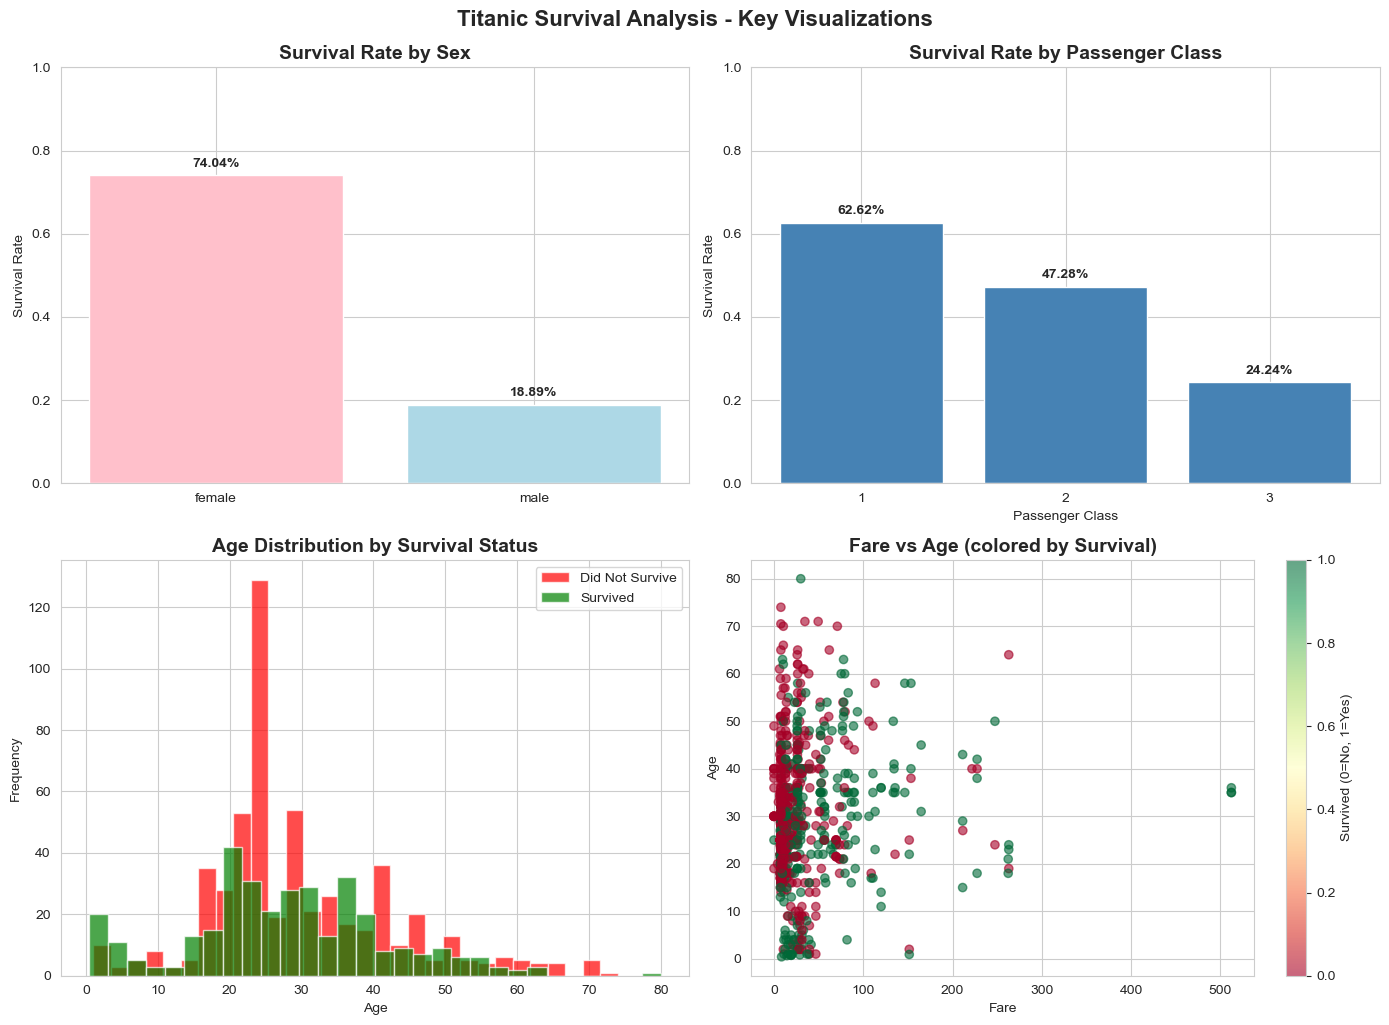

In [15]:
# Visualization 1: Survival rate by different factors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival rate by Sex
sex_survival = df_clean.groupby('Sex')['Survived'].mean()
axes[0, 0].bar(sex_survival.index, sex_survival.values, color=['pink', 'lightblue'])
axes[0, 0].set_title('Survival Rate by Sex', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Survival Rate')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(sex_survival.values):
    axes[0, 0].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

# 2. Survival rate by Pclass
pclass_survival = df_clean.groupby('Pclass')['Survived'].mean()
axes[0, 1].bar(pclass_survival.index.astype(str), pclass_survival.values, color='steelblue')
axes[0, 1].set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Passenger Class')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(pclass_survival.values):
    axes[0, 1].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

# 3. Age distribution by survival
axes[1, 0].hist(df_clean[df_clean['Survived']==0]['Age'], bins=30, alpha=0.7, label='Did Not Survive', color='red')
axes[1, 0].hist(df_clean[df_clean['Survived']==1]['Age'], bins=30, alpha=0.7, label='Survived', color='green')
axes[1, 0].set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 4. Fare vs Age colored by survival
scatter = axes[1, 1].scatter(df_clean['Fare'], df_clean['Age'], 
                            c=df_clean['Survived'], cmap='RdYlGn', alpha=0.6)
axes[1, 1].set_title('Fare vs Age (colored by Survival)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Fare')
axes[1, 1].set_ylabel('Age')
plt.colorbar(scatter, ax=axes[1, 1], label='Survived (0=No, 1=Yes)')

plt.tight_layout()
plt.suptitle('Titanic Survival Analysis - Key Visualizations', fontsize=16, fontweight='bold', y=1.02)
plt.show()

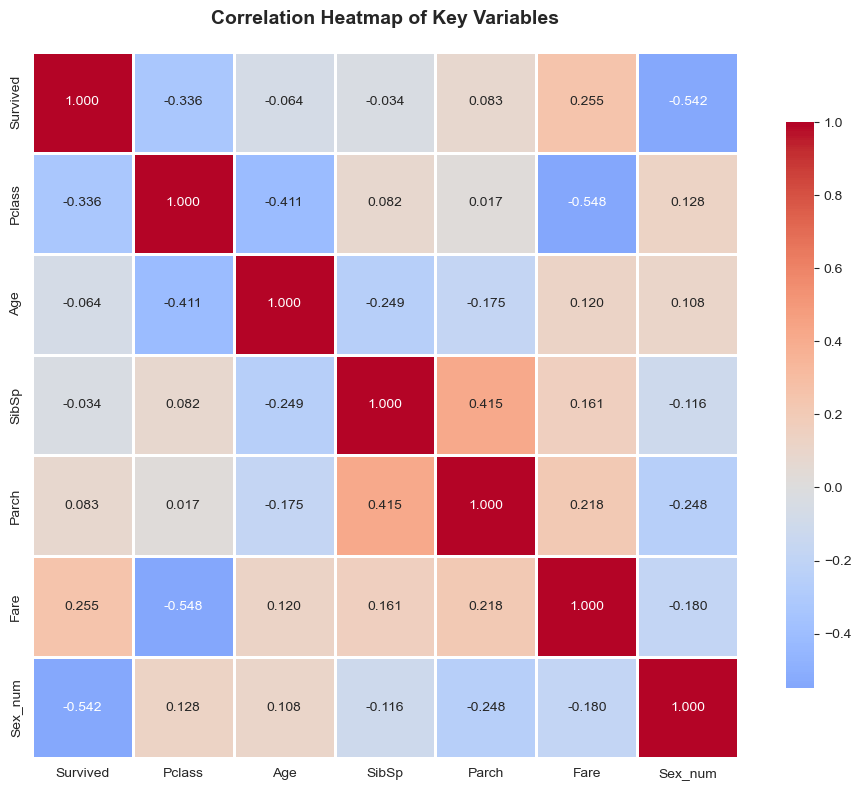

In [16]:
# Visualization 2: Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix_viz = df_clean[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_num']].corr()
sns.heatmap(correlation_matrix_viz, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Key Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

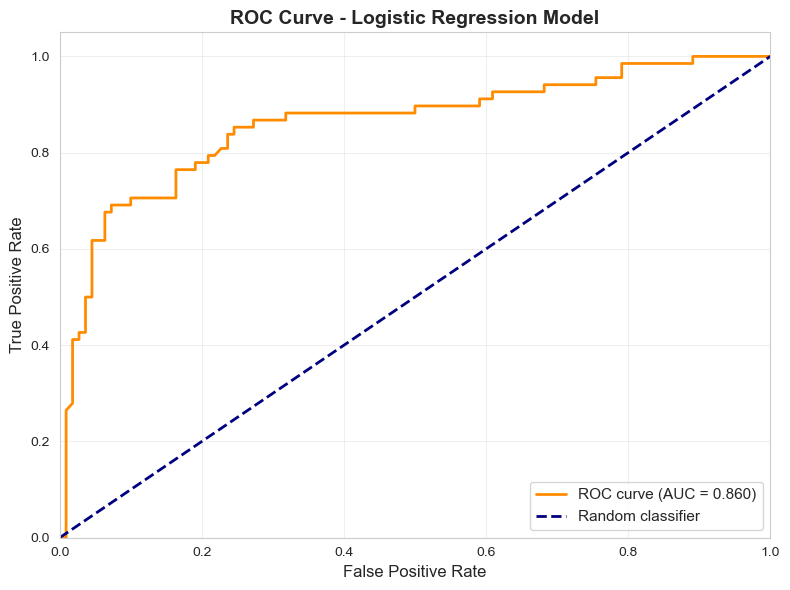

Area Under ROC Curve (AUC): 0.8598
AUC interpretation: 1.0 = perfect classifier, 0.5 = random classifier


In [17]:
# Visualization 3: Model performance - ROC Curve
# Calculate ROC curve for test set
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Area Under ROC Curve (AUC): {roc_auc:.4f}")
print("AUC interpretation: 1.0 = perfect classifier, 0.5 = random classifier")

## Summary and Conclusions

### Key Findings:

1. **Data Quality**: The dataset contained significant missing data, particularly in Age (19.9%) and Cabin (77.1%). We handled this through imputation and dropping unusable columns.

2. **Statistical Test**: The two-sample t-test revealed a statistically significant difference in mean age between survivors and non-survivors (p < 0.05).

3. **Variable Relationships**: 
   - Sex showed the strongest correlation with survival (-0.54), with females having much higher survival rates
   - Passenger class (Pclass) was also strongly correlated with survival (-0.34)
   - Fare showed a positive correlation with survival (0.26)

4. **Causal Interpretation**: The correlation between sex and survival cannot be interpreted causally due to confounding factors like the "women and children first" evacuation protocol.

5. **Predictive Model**: 
   - Logistic regression achieved ~81% accuracy on both training and test sets
   - The model shows good generalization with minimal overfitting
   - Key predictors: Sex, Pclass, and Fare were the most important features

6. **Visualizations**: Multiple visualizations revealed clear patterns in survival rates by sex, class, age, and fare.
